In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap, ZFeatureMap, TwoLocal
from qiskit.visualization import circuit_drawer
from qiskit.primitives import Sampler
from qiskit.circuit import ParameterVector
from sklearn.datasets import load_iris
import numpy as np

In [2]:
# ------------------------------------------------------------
# Step 1: Load Iris dataset
# ------------------------------------------------------------
iris = load_iris()
X = iris.data[:, :2]   # Take 2 features for simplicity
x_sample = X[0]        # Use one data point for encoding

# Normalize data (keep values within [0, π])
x_sample = np.pi * (x_sample - np.min(X)) / (np.max(X) - np.min(X))

In [3]:
# ------------------------------------------------------------
# Step 2: Design multiple quantum feature maps
# Each demonstrates a different quantum property
# ------------------------------------------------------------

hybrid_map = ZZFeatureMap(feature_dimension=2, reps=1)
zmap = ZFeatureMap(feature_dimension=2, reps=1)
new_params = ParameterVector('z', 2)
zmap = zmap.assign_parameters({zmap.parameters[i]: new_params[i] for i in range(2)})
hybrid_map = hybrid_map.compose(zmap)

feature_maps = {
    "ZFeatureMap (Superposition)": ZFeatureMap(feature_dimension=2, reps=2),
    "ZZFeatureMap (Entanglement)": ZZFeatureMap(feature_dimension=2, reps=2),
    "PauliFeatureMap (Interference)": PauliFeatureMap(feature_dimension=2, reps=2, paulis=['X', 'Y', 'Z']),
    "TwoLocal (Parameterized Entanglement)": TwoLocal(2, 'ry', 'cz', reps=2),
    "Custom Hybrid Map (Expressivity)": hybrid_map
}


ZFeatureMap (Superposition):



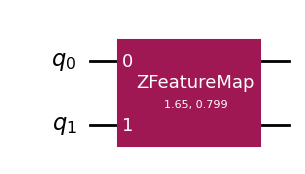

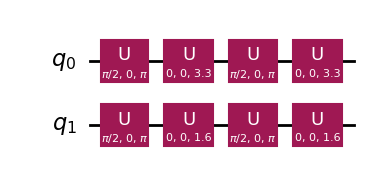


ZZFeatureMap (Entanglement):



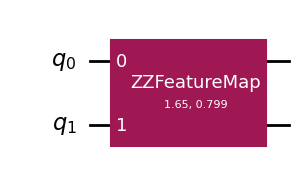

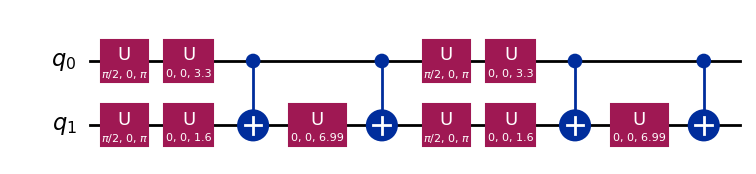


PauliFeatureMap (Interference):



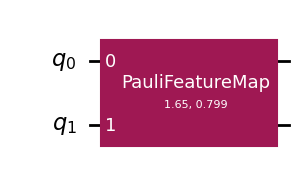

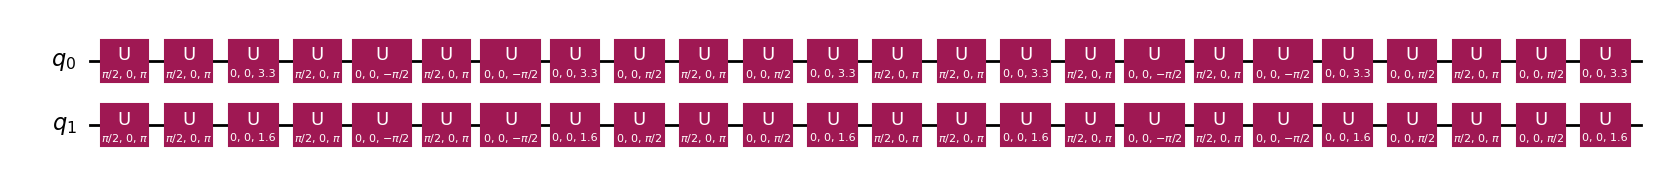


TwoLocal (Parameterized Entanglement):



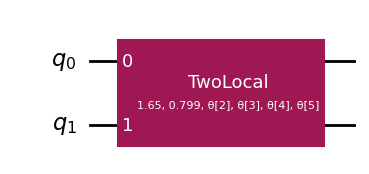

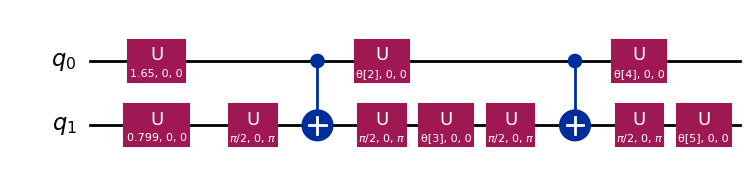


Custom Hybrid Map (Expressivity):



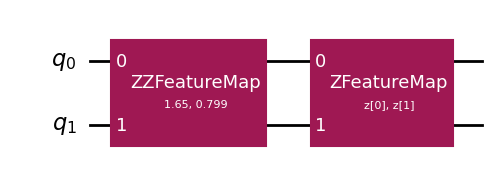

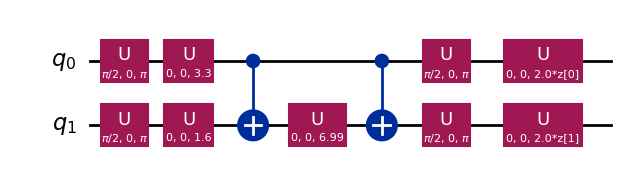

In [4]:
# ------------------------------------------------------------
# Step 3: Encode the data sample into each feature map
# ------------------------------------------------------------
encoded_circuits = []
for name, fmap in feature_maps.items():
    encoded = fmap.assign_parameters({fmap.parameters[i]: x_sample[i] for i in range(2)})
    encoded_circuits.append((name, encoded))
    print(f"\n{name}:\n")
    display(encoded.draw('mpl'))
    display(encoded.decompose(reps=10).draw('mpl'))

In [5]:
# ------------------------------------------------------------
# Step 4: Simulate one of the circuits to verify (ZZFeatureMap)
# ------------------------------------------------------------
backend = Aer.get_backend('statevector_simulator')
qc = encoded_circuits[1][1]
tqc = transpile(qc, backend)
result = backend.run(tqc).result()
state = result.get_statevector()
print("Statevector for ZZFeatureMap encoding:\n", state)

Statevector for ZZFeatureMap encoding:
 Statevector([-0.03291457-0.24920241j,  0.34256802-0.55615371j,
             -0.04109822+0.2418891j , -0.12203778-0.65959258j],
            dims=(2, 2))
